# Atlassian Datathon — Correlation + Missing Values EDA

This notebook looks at:

- correlations between support and usage variables
- whether missing values follow any pattern
- what happens if missing CSAT is temporarily treated as 0
- whether missingness itself could be useful information


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20

sns.set_theme(style="whitegrid")


C:\Users\Maxim\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load data

In [2]:
customers = pd.read_csv("data/customers.csv")
tickets = pd.read_csv("data/customer_support_tickets.csv")
usage = pd.read_csv("data/product_usage.csv")

print("Customers:", customers.shape)
print("Tickets:", tickets.shape)
print("Usage:", usage.shape)


Customers: (8320, 10)
Tickets: (8469, 16)
Usage: (42210, 8)


## Quick cleaning

In [3]:
customers["Account Created Date"] = pd.to_datetime(
    customers["Account Created Date"],
    errors="coerce"
)

tickets["Date of Purchase"] = pd.to_datetime(
    tickets["Date of Purchase"],
    dayfirst=True,
    errors="coerce"
)

tickets["First Response Time"] = pd.to_datetime(
    tickets["First Response Time"],
    dayfirst=True,
    errors="coerce"
)

tickets["Time to Resolution"] = pd.to_datetime(
    tickets["Time to Resolution"],
    dayfirst=True,
    errors="coerce"
)

usage["Month"] = pd.to_datetime(
    usage["Month"],
    errors="coerce"
)

print("Customer duplicates:", customers.duplicated().sum())
print("Ticket duplicates:", tickets.duplicated().sum())
print("Usage duplicates:", usage.duplicated().sum())


Customer duplicates: 0
Ticket duplicates: 0
Usage duplicates: 0


The IBM/DataSoc example does three useful things before modelling: fix data types, inspect missing values, and create useful new features. We'll follow the same idea here.

## Missing values overview

In [4]:
missing = pd.DataFrame({
    "missing": tickets.isna().sum(),
    "missing_pct": tickets.isna().mean() * 100
}).sort_values("missing_pct", ascending=False)

missing


,missing,missing_pct
Customer Satisfaction Rating,5700,67.30
Time to Resolution,5700,67.30
Resolution,5700,67.30
First Response Time,2819,33.29
Ticket ID,0,0.00
Customer Name,0,0.00
Customer Email,0,0.00
Customer Age,0,0.00
Ticket Type,0,0.00
Date of Purchase,0,0.00


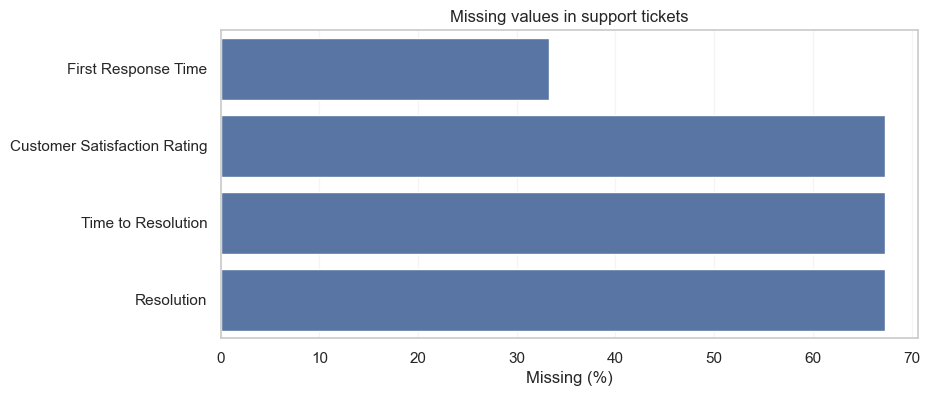

In [5]:
missing_plot = missing[missing["missing"] > 0].sort_values("missing_pct")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=missing_plot.reset_index(),
    x="missing_pct",
    y="index"
)
plt.title("Missing values in support tickets")
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.show()


## Are the missing values connected?

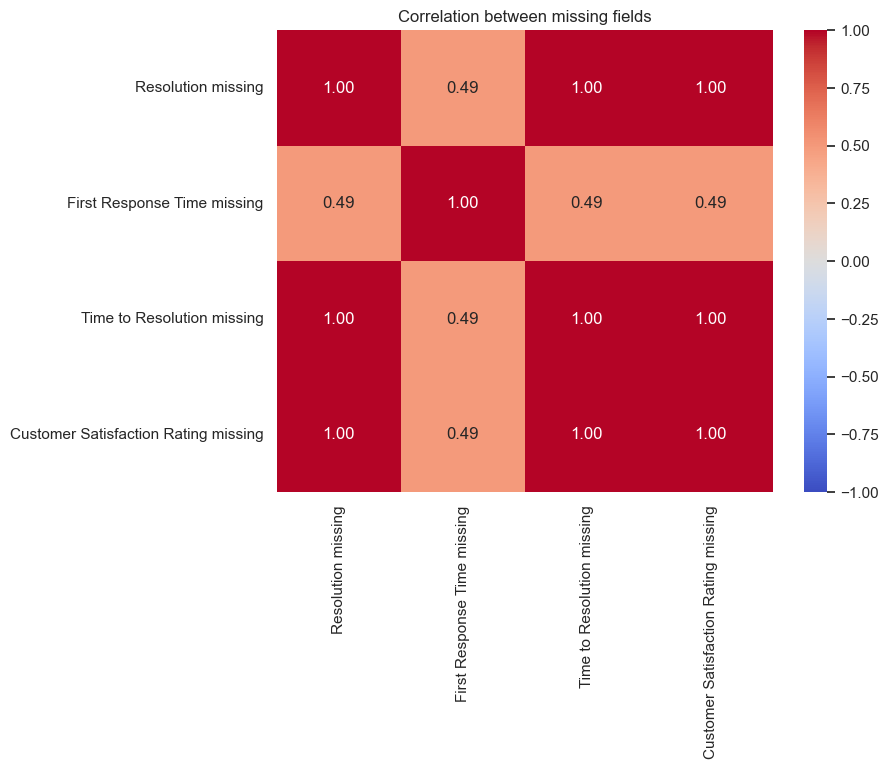

In [6]:
missing_cols = [
    "Resolution",
    "First Response Time",
    "Time to Resolution",
    "Customer Satisfaction Rating"
]

missing_flags = pd.DataFrame({
    col + " missing": tickets[col].isna().astype(int)
    for col in missing_cols
})

missing_corr = missing_flags.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    missing_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)
plt.title("Correlation between missing fields")
plt.show()


If two missing-value flags have a correlation close to 1, they usually go missing together. That can tell us whether the missingness comes from the same process.

## Missingness by ticket status

In [7]:
status_missing = (
    tickets.groupby("Ticket Status")
    .agg(
        tickets=("Ticket ID", "count"),
        resolution_missing_pct=("Resolution", lambda x: x.isna().mean() * 100),
        first_response_missing_pct=("First Response Time", lambda x: x.isna().mean() * 100),
        resolution_time_missing_pct=("Time to Resolution", lambda x: x.isna().mean() * 100),
        csat_missing_pct=("Customer Satisfaction Rating", lambda x: x.isna().mean() * 100),
    )
    .round(2)
)

status_missing


,tickets,resolution_missing_pct,first_response_missing_pct,resolution_time_missing_pct,csat_missing_pct
Ticket Status,,,,,
Closed,2769,0.00,0.00,0.00,0.00
Open,2819,100.00,100.00,100.00,100.00
Pending Customer Response,2881,100.00,0.00,100.00,100.00


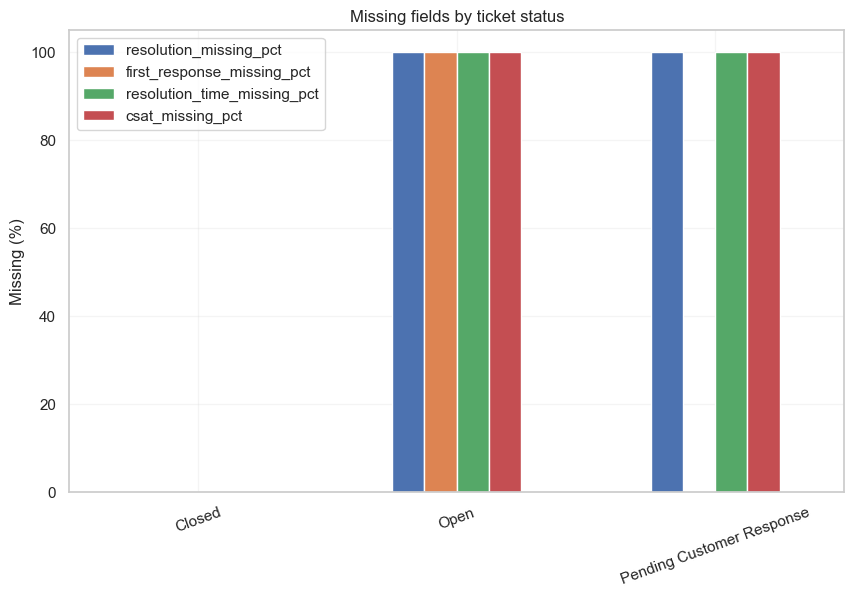

In [8]:
status_missing[
    [
        "resolution_missing_pct",
        "first_response_missing_pct",
        "resolution_time_missing_pct",
        "csat_missing_pct"
    ]
].plot(kind="bar")

plt.title("Missing fields by ticket status")
plt.xlabel("")
plt.ylabel("Missing (%)")
plt.xticks(rotation=20)
plt.legend(title="")
plt.show()


This is important because missing CSAT may not be random. If it mostly belongs to open / unresolved tickets, the missing value itself tells us something about the customer experience.

## Test whether missingness is associated with other variables

In [9]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = table.shape

    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1)
    )
    r_corrected = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corrected = k - ((k - 1) ** 2) / max(n - 1, 1)

    denominator = min(k_corrected - 1, r_corrected - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2_corrected / denominator)


In [10]:
tickets_customer = tickets.merge(
    customers[[
        "Customer ID",
        "Customer Email",
        "Plan Type",
        "Industry",
        "Region",
        "Company Size"
    ]],
    on="Customer Email",
    how="left",
    validate="many_to_one"
)

tickets_customer["CSAT Missing"] = (
    tickets_customer["Customer Satisfaction Rating"].isna()
)

tickets_customer["First Response Missing"] = (
    tickets_customer["First Response Time"].isna()
)

variables = [
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel",
    "Ticket Type",
    "Product Purchased",
    "Plan Type",
    "Company Size",
    "Region",
    "Industry"
]

missing_assoc = []

for col in variables:
    missing_assoc.append({
        "variable": col,
        "csat_missing_cramers_v": cramers_v(
            tickets_customer[col],
            tickets_customer["CSAT Missing"]
        ),
        "first_response_missing_cramers_v": cramers_v(
            tickets_customer[col],
            tickets_customer["First Response Missing"]
        )
    })

missing_assoc = (
    pd.DataFrame(missing_assoc)
    .sort_values("csat_missing_cramers_v", ascending=False)
    .round(3)
)

missing_assoc


,variable,csat_missing_cramers_v,first_response_missing_cramers_v
0,Ticket Status,1.00,1.00
8,Industry,0.04,0.00
1,Ticket Priority,0.02,0.00
3,Ticket Type,0.01,0.00
7,Region,0.01,0.04
4,Product Purchased,0.01,0.01
6,Company Size,0.01,0.00
2,Ticket Channel,0.00,0.00
5,Plan Type,0.00,0.00


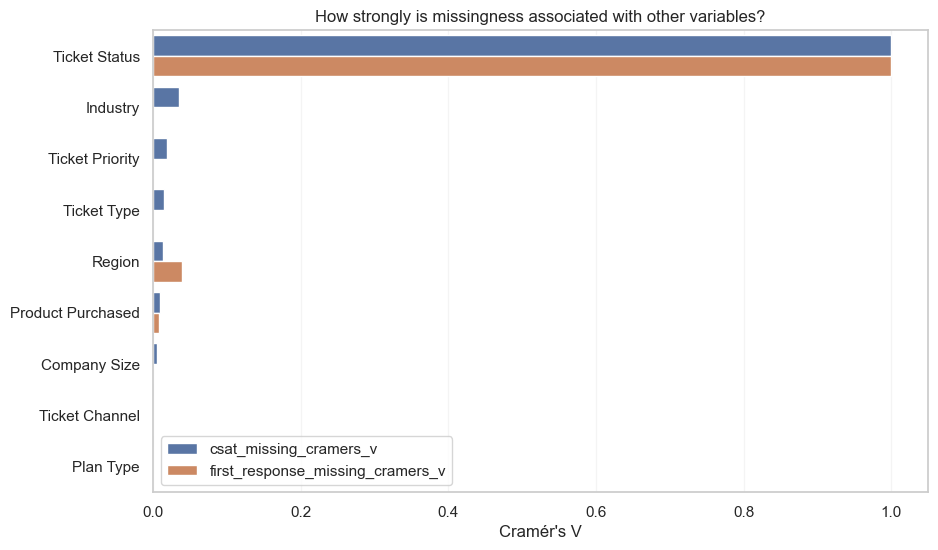

In [11]:
assoc_long = missing_assoc.melt(
    id_vars="variable",
    value_vars=[
        "csat_missing_cramers_v",
        "first_response_missing_cramers_v"
    ],
    var_name="missing_field",
    value_name="cramers_v"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=assoc_long,
    x="cramers_v",
    y="variable",
    hue="missing_field"
)

plt.title("How strongly is missingness associated with other variables?")
plt.xlabel("Cramér's V")
plt.ylabel("")
plt.legend(title="")
plt.show()


Cramér's V is useful here because most of these variables are categorical. Bigger values mean a stronger relationship between the category and whether the field is missing.

## Correlation heatmap — product usage

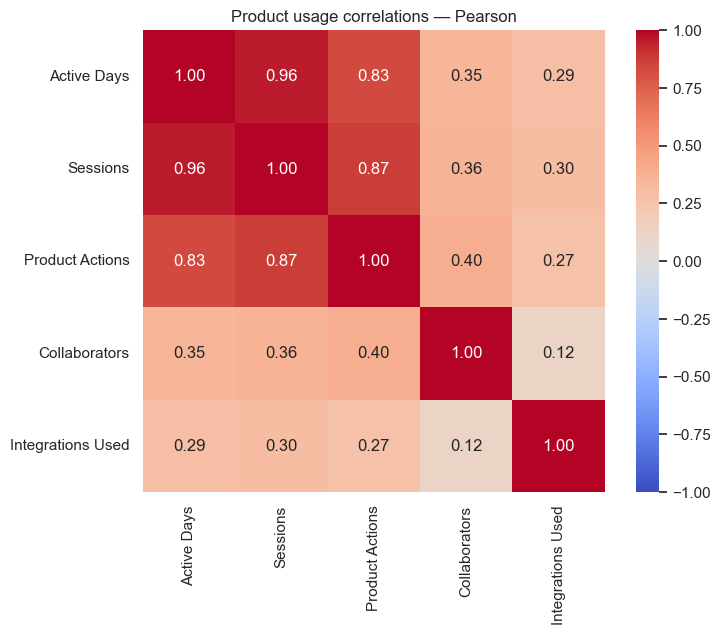

In [12]:
usage_numeric = usage[[
    "Active Days",
    "Sessions",
    "Product Actions",
    "Collaborators",
    "Integrations Used"
]]

usage_corr = usage_numeric.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    usage_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title("Product usage correlations — Pearson")
plt.show()


## Spearman heatmap

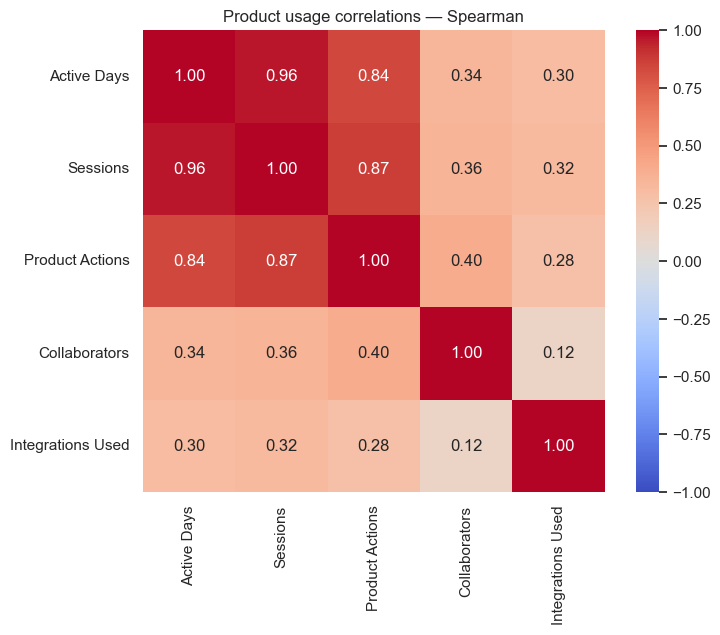

In [13]:
usage_spearman = usage_numeric.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    usage_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title("Product usage correlations — Spearman")
plt.show()


Pearson looks for linear relationships. Spearman is based on ranks, so it is a bit more robust when the data is skewed or the relationship is not perfectly linear.

## Build a customer-level dataset

In [14]:
monthly_usage = (
    usage.groupby(["Customer ID", "Month"], as_index=False)
    .agg(
        monthly_sessions=("Sessions", "sum"),
        monthly_actions=("Product Actions", "sum"),
        monthly_active_days=("Active Days", "sum"),
        monthly_collaborators=("Collaborators", "sum"),
        monthly_integrations=("Integrations Used", "sum")
    )
)

customer_usage = (
    monthly_usage.groupby("Customer ID")
    .agg(
        avg_monthly_sessions=("monthly_sessions", "mean"),
        avg_monthly_actions=("monthly_actions", "mean"),
        avg_monthly_active_days=("monthly_active_days", "mean"),
        avg_monthly_collaborators=("monthly_collaborators", "mean"),
        avg_monthly_integrations=("monthly_integrations", "mean")
    )
    .reset_index()
)

products_used = (
    usage.groupby("Customer ID")["Product"]
    .nunique()
    .rename("products_used")
    .reset_index()
)

monthly_sessions = (
    monthly_usage[[
        "Customer ID",
        "Month",
        "monthly_sessions"
    ]]
    .sort_values(["Customer ID", "Month"])
)

usage_change = (
    monthly_sessions.groupby("Customer ID")
    .agg(
        first_sessions=("monthly_sessions", "first"),
        last_sessions=("monthly_sessions", "last")
    )
    .reset_index()
)

usage_change["session_change_pct"] = np.where(
    usage_change["first_sessions"] > 0,
    (
        usage_change["last_sessions"]
        - usage_change["first_sessions"]
    )
    / usage_change["first_sessions"] * 100,
    np.nan
)

customer_usage = (
    customer_usage
    .merge(products_used, on="Customer ID", how="left")
    .merge(usage_change, on="Customer ID", how="left")
)

customer_usage.head()


,Customer ID,avg_monthly_sessions,avg_monthly_actions,avg_monthly_active_days,avg_monthly_collaborators,avg_monthly_integrations,products_used,first_sessions,last_sessions,session_change_pct
0,CUST00001,8.20,37.80,4.20,7.40,2.80,1,7,10,42.86
1,CUST00002,13.20,74.80,6.20,12.20,2.80,1,19,11,-42.11
2,CUST00003,8.60,38.60,4.60,10.00,1.20,1,14,4,-71.43
3,CUST00004,39.80,279.00,19.40,13.40,6.00,1,33,42,27.27
4,CUST00005,8.80,34.60,5.00,6.80,2.20,1,10,12,20.00


In [15]:
customer_support = (
    tickets_customer.groupby("Customer ID")
    .agg(
        ticket_count=("Ticket ID", "count"),
        avg_csat=("Customer Satisfaction Rating", "mean"),
        critical_tickets=("Ticket Priority", lambda x: (x == "Critical").sum()),
        unresolved_tickets=("Ticket Status", lambda x: (x != "Closed").sum()),
        missing_csat_tickets=("Customer Satisfaction Rating", lambda x: x.isna().sum()),
        missing_response_tickets=("First Response Time", lambda x: x.isna().sum())
    )
    .reset_index()
)

customer_full = (
    customers
    .merge(customer_usage, on="Customer ID", how="left")
    .merge(customer_support, on="Customer ID", how="left")
)

customer_full["account_age_days_at_2023"] = (
    pd.Timestamp("2023-01-01")
    - customer_full["Account Created Date"]
).dt.days

for col in [
    "ticket_count",
    "critical_tickets",
    "unresolved_tickets",
    "missing_csat_tickets",
    "missing_response_tickets"
]:
    customer_full[col] = customer_full[col].fillna(0)

customer_full.head()


,Customer ID,Customer Name,Customer Email,Customer Age,Customer Gender,Industry,Region,Company Size,Plan Type,Account Created Date,avg_monthly_sessions,avg_monthly_actions,avg_monthly_active_days,avg_monthly_collaborators,avg_monthly_integrations,products_used,first_sessions,last_sessions,session_change_pct,ticket_count,avg_csat,critical_tickets,unresolved_tickets,missing_csat_tickets,missing_response_tickets,account_age_days_at_2023
0,CUST00001,Robert Downs,aanderson@example.com,42,Male,Technology,Europe,201-500,Standard,2020-12-20,8.20,37.80,4.20,7.40,2.80,1,7,10,42.86,1,NaN,0,1,1,1,742
1,CUST00002,Cesar Jensen,aanderson@example.net,35,Other,Retail,Asia-Pacific,201-500,Standard,2020-06-15,13.20,74.80,6.20,12.20,2.80,1,19,11,-42.11,1,NaN,0,1,1,0,930
2,CUST00003,Angela Tran,aarnold@example.com,52,Other,Education,Asia-Pacific,1000+,Free,2020-10-24,8.60,38.60,4.60,10.00,1.20,1,14,4,-71.43,1,5.00,0,0,0,0,799
3,CUST00004,Justin Estrada,aaron01@example.com,45,Female,Professional Services,Europe,11-50,Enterprise,2019-11-13,39.80,279.00,19.40,13.40,6.00,1,33,42,27.27,1,NaN,0,1,1,1,1145
4,CUST00005,James Santos,aaron49@example.org,22,Other,Professional Services,Australia & New Zealand,501-1000,Standard,2019-04-21,8.80,34.60,5.00,6.80,2.20,1,10,12,20.00,1,NaN,0,1,1,1,1351


## Customer-level correlation heatmap

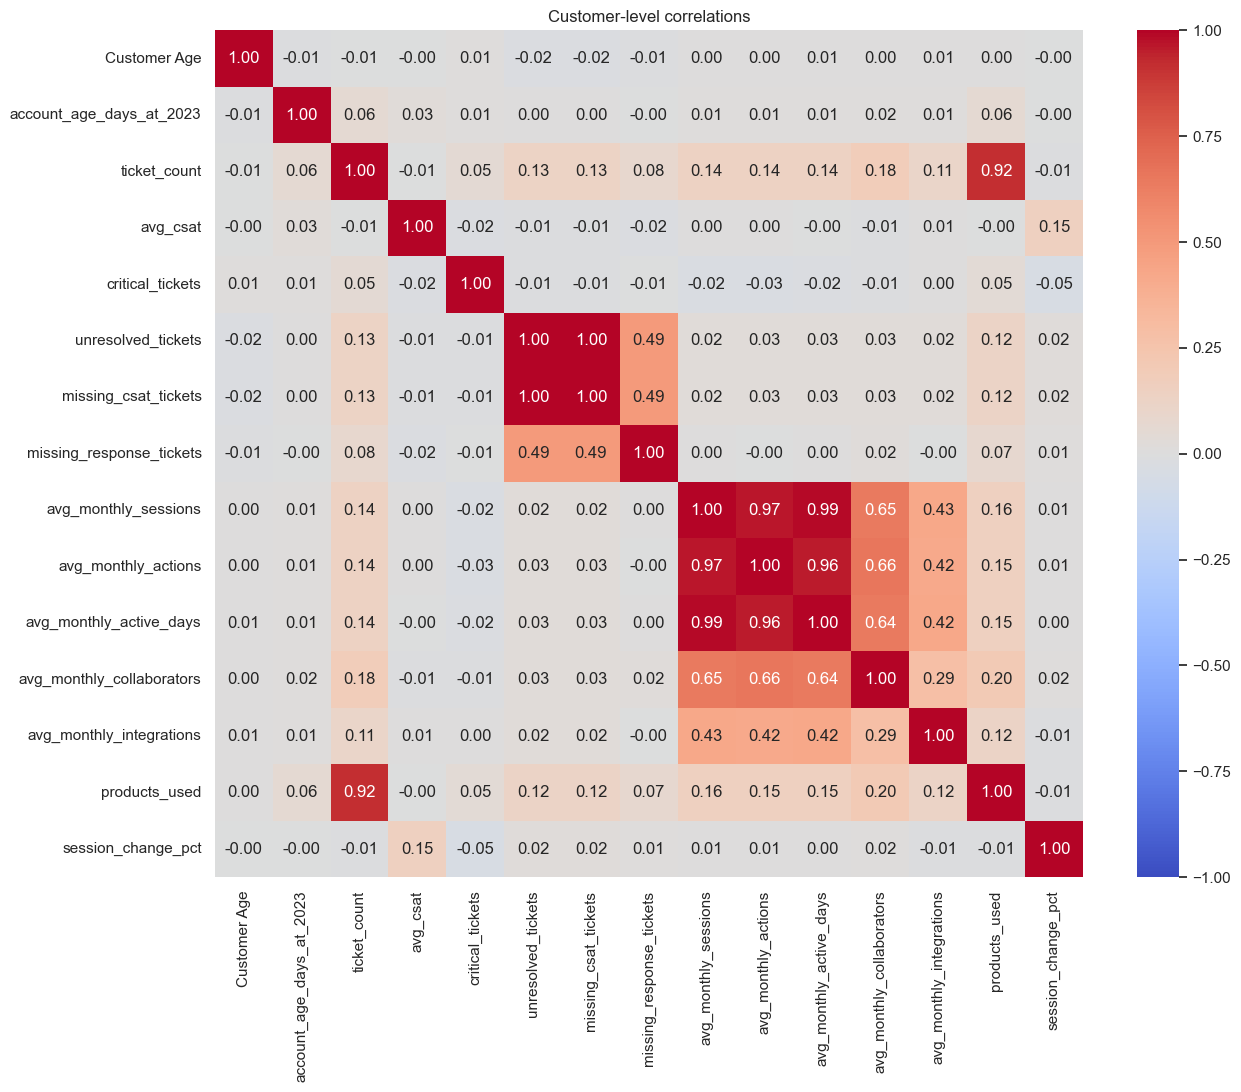

In [16]:
customer_corr_cols = [
    "Customer Age",
    "account_age_days_at_2023",
    "ticket_count",
    "avg_csat",
    "critical_tickets",
    "unresolved_tickets",
    "missing_csat_tickets",
    "missing_response_tickets",
    "avg_monthly_sessions",
    "avg_monthly_actions",
    "avg_monthly_active_days",
    "avg_monthly_collaborators",
    "avg_monthly_integrations",
    "products_used",
    "session_change_pct"
]

customer_corr = (
    customer_full[customer_corr_cols]
    .corr(method="spearman")
)

plt.figure(figsize=(14, 11))
sns.heatmap(
    customer_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Customer-level correlations")
plt.show()


This is one of the main heatmaps to inspect. Look especially at `avg_csat`, `ticket_count`, `unresolved_tickets`, `missing_csat_tickets` and the usage variables.

## Strongest correlations

In [17]:
corr_pairs = (
    customer_corr
    .where(np.triu(np.ones(customer_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
).head(20)


,variable_1,variable_2,correlation,abs_correlation
81,unresolved_tickets,missing_csat_tickets,1.00,1.00
130,avg_monthly_sessions,avg_monthly_active_days,0.99,0.99
129,avg_monthly_sessions,avg_monthly_actions,0.97,0.97
145,avg_monthly_actions,avg_monthly_active_days,0.96,0.96
43,ticket_count,products_used,0.92,0.92
146,avg_monthly_actions,avg_monthly_collaborators,0.66,0.66
131,avg_monthly_sessions,avg_monthly_collaborators,0.65,0.65
161,avg_monthly_active_days,avg_monthly_collaborators,0.64,0.64
82,unresolved_tickets,missing_response_tickets,0.49,0.49
97,missing_csat_tickets,missing_response_tickets,0.49,0.49


## Missing CSAT: present vs missing

In [18]:
ticket_csat_groups = (
    tickets_customer
    .assign(
        csat_available=np.where(
            tickets_customer["Customer Satisfaction Rating"].notna(),
            "CSAT present",
            "CSAT missing"
        )
    )
)

pd.crosstab(
    ticket_csat_groups["Ticket Status"],
    ticket_csat_groups["csat_available"],
    normalize="index"
).mul(100).round(2)


csat_available,CSAT missing,CSAT present
Ticket Status,,
Closed,0.00,100.00
Open,100.00,0.00
Pending Customer Response,100.00,0.00


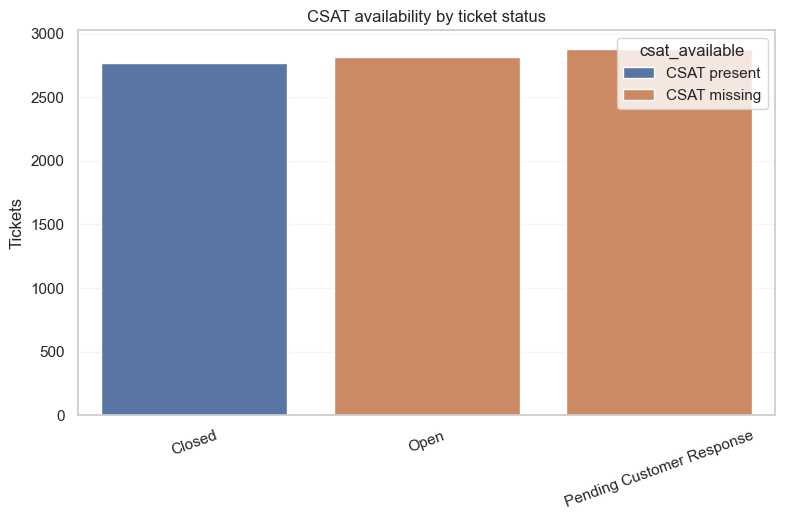

In [19]:
status_csat_availability = (
    ticket_csat_groups.groupby(["Ticket Status", "csat_available"])
    .size()
    .reset_index(name="tickets")
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=status_csat_availability,
    x="Ticket Status",
    y="tickets",
    hue="csat_available"
)

plt.title("CSAT availability by ticket status")
plt.xlabel("")
plt.ylabel("Tickets")
plt.xticks(rotation=20)
plt.show()


## Zero-fill experiment

This is only an experiment.

A missing CSAT does **not** literally mean a score of 0. But filling it with 0 can show us what happens if we treat missingness as a strong negative signal.

If the story changes dramatically, that tells us missingness is important and should probably be modelled separately rather than silently dropped.


In [20]:
tickets_zero = tickets_customer.copy()

tickets_zero["CSAT Original"] = (
    tickets_zero["Customer Satisfaction Rating"]
)

tickets_zero["CSAT Zero Filled"] = (
    tickets_zero["Customer Satisfaction Rating"]
    .fillna(0)
)

print(
    "Original mean CSAT:",
    round(tickets_zero["CSAT Original"].mean(), 2)
)

print(
    "Zero-filled mean CSAT:",
    round(tickets_zero["CSAT Zero Filled"].mean(), 2)
)


Original mean CSAT: 2.99
Zero-filled mean CSAT: 0.98


## Original vs zero-filled CSAT by plan

In [21]:
plan_csat_compare = (
    tickets_zero.groupby("Plan Type")
    .agg(
        original_avg_csat=("CSAT Original", "mean"),
        zero_filled_avg_csat=("CSAT Zero Filled", "mean"),
        csat_missing_pct=("CSAT Original", lambda x: x.isna().mean() * 100)
    )
    .round(2)
)

plan_csat_compare


,original_avg_csat,zero_filled_avg_csat,csat_missing_pct
Plan Type,,,
Enterprise,3.04,0.99,67.60
Free,3.02,1.00,66.93
Premium,2.99,0.97,67.65
Standard,2.96,0.97,67.12


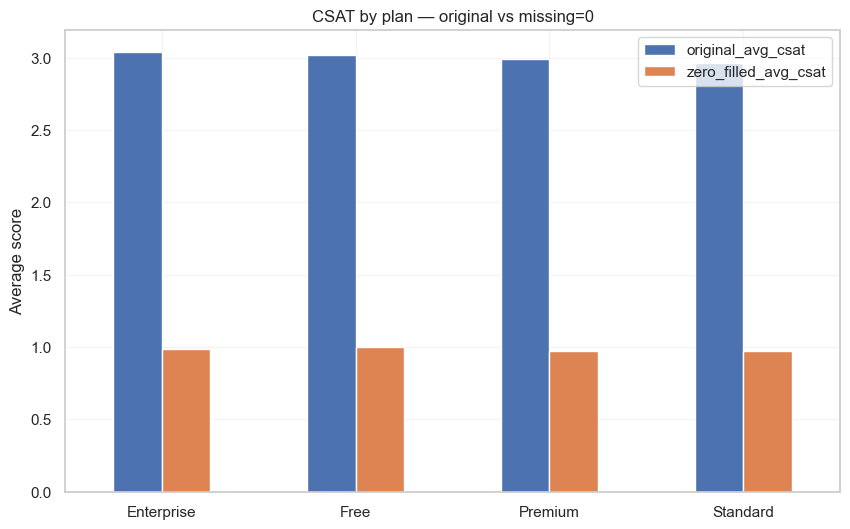

In [22]:
plan_csat_compare[
    ["original_avg_csat", "zero_filled_avg_csat"]
].plot(kind="bar")

plt.title("CSAT by plan — original vs missing=0")
plt.xlabel("")
plt.ylabel("Average score")
plt.xticks(rotation=0)
plt.show()


## Original vs zero-filled CSAT by product

In [23]:
product_csat_compare = (
    tickets_zero.groupby("Product Purchased")
    .agg(
        tickets=("Ticket ID", "count"),
        original_avg_csat=("CSAT Original", "mean"),
        zero_filled_avg_csat=("CSAT Zero Filled", "mean"),
        csat_missing_pct=("CSAT Original", lambda x: x.isna().mean() * 100)
    )
    .round(2)
    .sort_values("zero_filled_avg_csat")
)

product_csat_compare


,tickets,original_avg_csat,zero_filled_avg_csat,csat_missing_pct
Product Purchased,,,,
Confluence,1831,3.02,0.93,69.25
Bitbucket,1595,2.94,0.97,66.96
Jira,1787,2.96,0.97,67.38
Trello,1627,2.97,1.01,65.95
Loom,1629,3.06,1.02,66.73


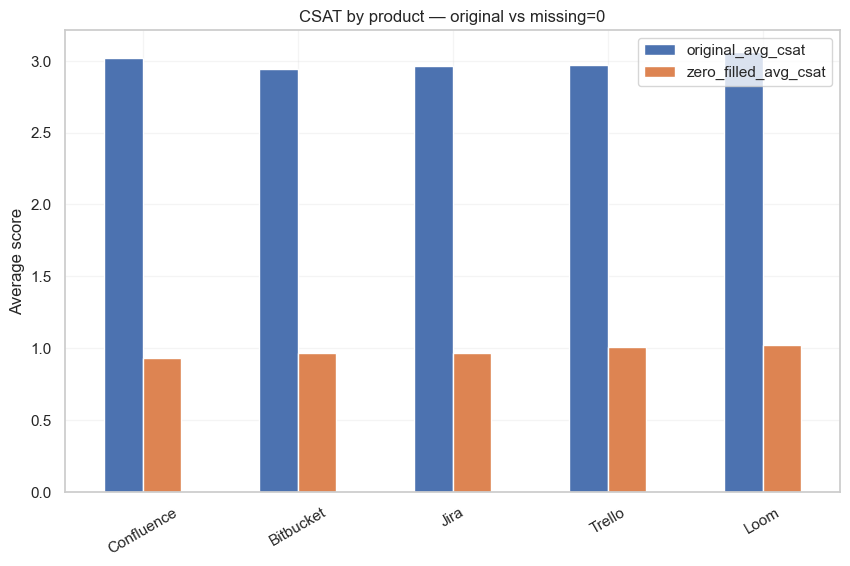

In [24]:
product_csat_compare[
    ["original_avg_csat", "zero_filled_avg_csat"]
].plot(kind="bar")

plt.title("CSAT by product — original vs missing=0")
plt.xlabel("")
plt.ylabel("Average score")
plt.xticks(rotation=30)
plt.show()


## Does missing CSAT line up with weaker product usage?

In [25]:
customer_missing = (
    tickets_customer.groupby("Customer ID")
    .agg(
        tickets=("Ticket ID", "count"),
        csat_available_tickets=(
            "Customer Satisfaction Rating",
            lambda x: x.notna().sum()
        ),
        csat_missing_tickets=(
            "Customer Satisfaction Rating",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

customer_missing["all_csat_missing"] = (
    customer_missing["csat_available_tickets"] == 0
)

missing_usage = (
    customer_missing
    .merge(customer_usage, on="Customer ID", how="left")
    .groupby("all_csat_missing")
    .agg(
        customers=("Customer ID", "nunique"),
        median_monthly_sessions=("avg_monthly_sessions", "median"),
        median_monthly_actions=("avg_monthly_actions", "median"),
        median_products_used=("products_used", "median"),
        median_session_change_pct=("session_change_pct", "median")
    )
    .round(2)
)

missing_usage.index = [
    "Has at least one CSAT",
    "All CSAT missing"
]

missing_usage


,customers,median_monthly_sessions,median_monthly_actions,median_products_used,median_session_change_pct
Has at least one CSAT,2749,15.80,90.00,1.00,0.00
All CSAT missing,5571,15.80,89.60,1.00,0.00


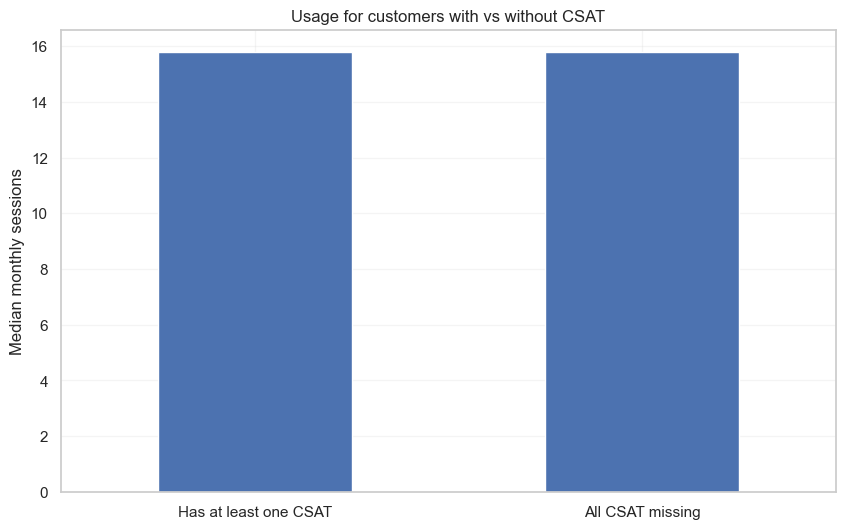

In [26]:
missing_usage["median_monthly_sessions"].plot(kind="bar")

plt.title("Usage for customers with vs without CSAT")
plt.xlabel("")
plt.ylabel("Median monthly sessions")
plt.xticks(rotation=0)
plt.show()


## Missing first response by group

In [27]:
def missing_rate_by_group(df, group_col, target_col):
    return (
        df.groupby(group_col)[target_col]
        .apply(lambda x: x.isna().mean() * 100)
        .sort_values(ascending=False)
        .round(2)
    )

for col in [
    "Ticket Status",
    "Product Purchased",
    "Ticket Priority",
    "Ticket Channel",
    "Plan Type",
    "Company Size"
]:
    print("\n", col.upper())
    display(
        missing_rate_by_group(
            tickets_customer,
            col,
            "First Response Time"
        ).to_frame("first_response_missing_pct")
    )



 TICKET STATUS


,first_response_missing_pct
Ticket Status,
Open,100.00
Closed,0.00
Pending Customer Response,0.00



 PRODUCT PURCHASED


,first_response_missing_pct
Product Purchased,
Confluence,35.34
Jira,32.96
Bitbucket,32.79
Trello,32.64
Loom,32.47



 TICKET PRIORITY


...

,first_response_missing_pct
Ticket Channel,
Phone,34.52
Chat,33.04
Social media,32.86
Email,32.71



 PLAN TYPE


,first_response_missing_pct
Plan Type,
Free,34.66
Premium,33.15
Standard,33.09
Enterprise,32.40



 COMPANY SIZE


,first_response_missing_pct
Company Size,
501-1000,35.24
1000+,34.12
1-10,33.56
51-200,33.28
201-500,32.85
11-50,32.10


## Missing CSAT by group

In [28]:
for col in [
    "Ticket Status",
    "Product Purchased",
    "Ticket Priority",
    "Ticket Channel",
    "Plan Type",
    "Company Size"
]:
    print("\n", col.upper())
    display(
        missing_rate_by_group(
            tickets_customer,
            col,
            "Customer Satisfaction Rating"
        ).to_frame("csat_missing_pct")
    )



 TICKET STATUS


,csat_missing_pct
Ticket Status,
Open,100.00
Pending Customer Response,100.00
Closed,0.00



 PRODUCT PURCHASED


,csat_missing_pct
Product Purchased,
Confluence,69.25
Jira,67.38
Bitbucket,66.96
Loom,66.73
Trello,65.95



 TICKET PRIORITY


...

,csat_missing_pct
Ticket Channel,
Social media,67.75
Phone,67.59
Chat,67.49
Email,66.40



 PLAN TYPE


,csat_missing_pct
Plan Type,
Premium,67.65
Enterprise,67.60
Standard,67.12
Free,66.93



 COMPANY SIZE


,csat_missing_pct
Company Size,
1000+,69.37
1-10,68.35
11-50,67.90
501-1000,66.96
51-200,66.93
201-500,65.44


## A few useful flags

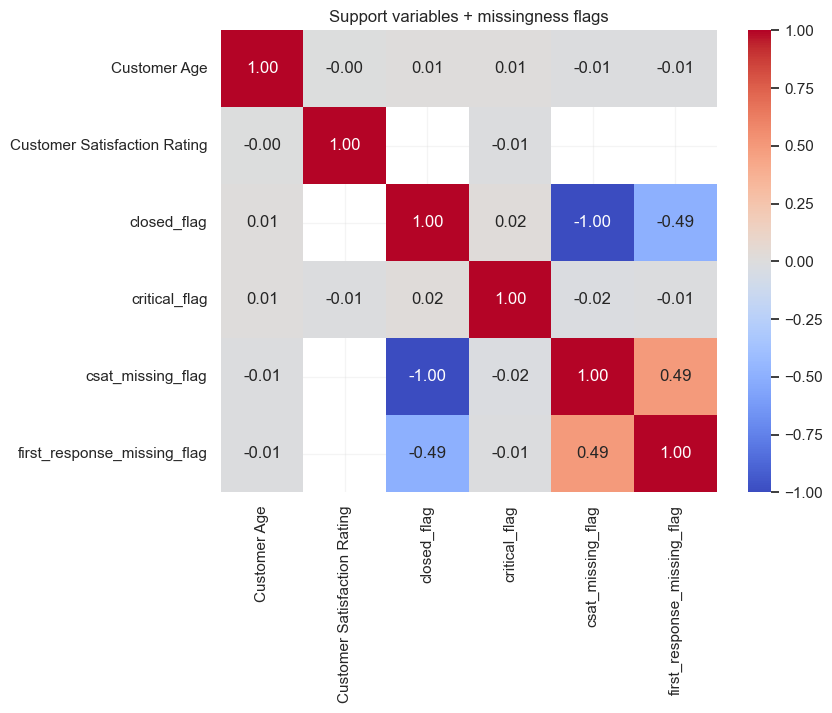

In [29]:
tickets_customer["closed_flag"] = (
    tickets_customer["Ticket Status"] == "Closed"
).astype(int)

tickets_customer["critical_flag"] = (
    tickets_customer["Ticket Priority"] == "Critical"
).astype(int)

tickets_customer["csat_missing_flag"] = (
    tickets_customer["Customer Satisfaction Rating"].isna()
).astype(int)

tickets_customer["first_response_missing_flag"] = (
    tickets_customer["First Response Time"].isna()
).astype(int)

flag_corr = tickets_customer[[
    "Customer Age",
    "Customer Satisfaction Rating",
    "closed_flag",
    "critical_flag",
    "csat_missing_flag",
    "first_response_missing_flag"
]].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    flag_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Support variables + missingness flags")
plt.show()
